# PDF Q&A Pipeline-Aligned Notebook
### Follows all 12 steps from the System Pipeline architecture diagram

**Two sections:** A (Offline Ingestion & Indexing) and B (Online Querying & Response Generation)

## SECTION A: DOCUMENT INGESTION & INDEXING (OFFLINE)
---

In [1]:
# STEP 1: Install dependencies
!pip install langchain langchain-community langchain-text-splitters faiss-cpu sentence-transformers pymupdf google-generativeai groq pillow flask flask-cors pyngrok -q
print('All packages installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
All packages installed!


In [ ]:
# STEP 2: Restart runtime after install
import os
os.kill(os.getpid(), 9)

In [ ]:
# STEP 3: API Keys (REDACTED)
import os
# Read keys from environment variables or replace with your own in a secure way.
GROQ_API_KEY    = os.environ.get("GROQ_API_KEY", "REDACTED_GROQ_API_KEY")      # https://console.groq.com
GEMINI_API_KEY  = os.environ.get("GEMINI_API_KEY", "REDACTED_GEMINI_API_KEY")    # https://aistudio.google.com

import google.generativeai as genai
from groq import Groq

genai.configure(api_key=GEMINI_API_KEY)
groq_client = Groq(api_key=GROQ_API_KEY)
print('API clients ready!')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


API clients ready!


### Pipeline Step 1 - Document Upload

In [2]:
# STEP 4: Upload PDF
# Option A: use sidebar (Files panel) — upload there and set filename below
# Option B: run files.upload() widget
import os

USE_SIDEBAR = False  # set True if you upload via the Files panel

if USE_SIDEBAR:
    filename = 'your_file.pdf'  # <-- change to your uploaded file name
    assert os.path.exists(filename), f'File not found: {filename}'
    print(f'Using: {filename}')
else:
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    print(f'Uploaded: {filename}')


Saving AI_Resume_Builder.pdf to AI_Resume_Builder.pdf
Uploaded: AI_Resume_Builder.pdf


### Pipeline Steps 2 & 3 - Document Processing + Text Extraction & Cleaning

> **What was missing:** The original notebook called `get_text()` directly with zero cleaning. Page numbers, headers, footers, and noise were all kept. Page and section metadata were never captured. Fixed below.

In [3]:
# STEP 5: Extract and CLEAN text with page/section structure
# Pipeline Step 2: Read doc, identify structure (pages, sections)
# Pipeline Step 3: Extract text, clean noise (headers, footers, page numbers)
import fitz
import re

def clean_text(text):
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'(?m)^\s*-?\s*\d+\s*-?\s*$', '', text)
    text = re.sub(r'(?m)^(Page \d+|\d+ of \d+|www\.\S+)$', '', text, flags=re.IGNORECASE)
    return text.strip()

def extract_structured_text(pdf_path):
    doc = fitz.open(pdf_path)
    pages_data = []
    print(f'Processing {len(doc)} pages...')
    for page_num, page in enumerate(doc, start=1):
        raw = page.get_text().strip()
        if not raw:
            continue
        cleaned = clean_text(raw)
        section = 'Unknown'
        for b in page.get_text('blocks'):
            line = b[4].strip()
            if line and len(line) < 80 and (line.isupper() or line.istitle()):
                section = line
                break
        pages_data.append({
            'page_num': page_num,
            'section': section,
            'cleaned_text': cleaned
        })
    full_text = '\n\n'.join([p['cleaned_text'] for p in pages_data])
    print(f'Extracted {len(full_text):,} chars from {len(pages_data)} pages')
    return pages_data, full_text

pages_data, full_cleaned_text = extract_structured_text(filename)
print('Preview:', full_cleaned_text[:300])

Processing 9 pages...
Extracted 19,164 chars from 9 pages
Preview: An Agent-Based AI Resume Generator with ATS
Optimization Using Natural Language Processing
Pratibha M. Patil1, Lata Rathod1, and Preeti Chalawadi1
KLE Technological University, Hubballi, Karnataka, India
01fe24bcs413@kletech.ac.in, 01fe24bcs409@kletech.ac.in,
01fe23bcs154@kletech.ac.in
Abstract. In 


### Pipeline Step 4 - Image/Diagram Extraction with Captions & Nearby Context

> **What was missing:** Images were extracted but captions and nearby text context were never captured. Images were also not linked to their surrounding document context. Fixed below.

In [4]:
# STEP 6: Extract images with caption and nearby context
# Pipeline Step 4: Extract figures, diagrams, tables, charts
#                  Capture captions and nearby context
import io, base64
from PIL import Image

def extract_images_with_context(pdf_path, pages_data):
    doc = fitz.open(pdf_path)
    page_text_map = {p['page_num']: p['cleaned_text'] for p in pages_data}
    images_info = []

    for page_num, page in enumerate(doc, start=1):
        for img_idx, img_info in enumerate(page.get_images(full=True)):
            try:
                base_img = doc.extract_image(img_info[0])
                pil_img = Image.open(io.BytesIO(base_img['image'])).convert('RGB')
                if pil_img.width < 50 or pil_img.height < 50:
                    continue  # skip tiny icons

                page_text = page_text_map.get(page_num, '')

                # Detect caption line (Figure X, Table X, Chart, Diagram)
                caption = ''
                for line in page_text.split('\n'):
                    if re.search(r'(fig(ure)?[.\s]\d+|table[.\s]\d+|chart|diagram)', line, re.IGNORECASE):
                        caption = line.strip()
                        break

                nearby_context = caption if caption else page_text[:200]

                images_info.append({
                    'page_num': page_num,
                    'img_idx': img_idx,
                    'pil_img': pil_img,
                    'caption': caption,
                    'nearby_context': nearby_context
                })
                tag = f'Caption: "{caption[:50]}"' if caption else 'no caption detected'
                print(f'  Image page {page_num} ({pil_img.width}x{pil_img.height}) | {tag}')
            except Exception as e:
                print(f'  Skipped page {page_num}: {e}')

    print(f'Extracted {len(images_info)} image(s) with context')
    return images_info

pdf_images = extract_images_with_context(filename, pages_data)

  Image page 4 (1536x1024) | no caption detected
  Image page 6 (571x455) | Caption: "Table 1. Keyword Matching Accuracy Comparison"
  Image page 7 (904x831) | Caption: "Table 2. Comparative ATS Performance of Resume Gen"
Extracted 3 image(s) with context


In [5]:
# STEP 7: Describe images using Groq Vision
# Passes caption and nearby context as a hint to the vision model
import time

def describe_image_with_groq(img_info):
    buf = io.BytesIO()
    img_info['pil_img'].save(buf, format='JPEG', quality=85)
    img_b64 = base64.b64encode(buf.getvalue()).decode()

    hint = (f'The image appears near this text: "{img_info["nearby_context"][:150]}"'
            if img_info['nearby_context'] else '')

    resp = groq_client.chat.completions.create(
        model='llama-3.1-8b-instant',
        messages=[{'role': 'user', 'content': prompt}],
        max_tokens=1024
    )
    return resp.choices[0].message.content

print('Describing images with vision model...')
for img in pdf_images:
    try:
        img['description'] = describe_image_with_groq(img)
        print(f'  Page {img["page_num"]}: {img["description"][:100]}...')
        time.sleep(2)
    except Exception as e:
        img['description'] = 'Description unavailable.'
        print(f'  Page {img["page_num"]} skipped: {e}')
        time.sleep(5)

print(f'Done! {len(pdf_images)} image(s) described.')

Describing images with vision model...
  Page 4 skipped: name 'prompt' is not defined
  Page 6 skipped: name 'prompt' is not defined
  Page 7 skipped: name 'prompt' is not defined
Done! 3 image(s) described.


### Pipeline Step 5 - Text Chunking

> **What was missing:** Chunks had no page/section metadata. Fixed: each chunk now carries `page_num`, `section`, and `source`.

In [6]:
# STEP 8: Text Chunking with page and section metadata
# Pipeline Step 5: Split cleaned text into chunks with overlap to preserve context
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=75)

text_docs = []
for page in pages_data:
    for chunk in splitter.split_text(page['cleaned_text']):
        text_docs.append(Document(
            page_content=chunk,
            metadata={
                'type': 'text',
                'page_num': page['page_num'],
                'section': page['section'],
                'source': filename
            }
        ))

print(f'Created {len(text_docs)} text chunks with metadata')
print(f'Sample: {text_docs[0].metadata}')

Created 53 text chunks with metadata
Sample: {'type': 'text', 'page_num': 1, 'section': '1\nIntroduction', 'source': 'AI_Resume_Builder.pdf'}


### Pipeline Steps 6 & 7 - Embedding Generation + Vector Database Storage

> **What was missing:** Image documents stored only page number. Fixed: now store `page_num`, `caption`, `img_idx`, and `source` as required by the pipeline spec (source, page no., section, image refs).

In [7]:
# STEP 9: Embedding Generation + FAISS Vector DB storage
# Pipeline Step 6: Convert text chunks to vector embeddings
# Pipeline Step 7: Store embeddings with metadata (source, page no., section, image refs)
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')

# Image documents with full metadata
img_docs = [
    Document(
        page_content=(
            f'[IMAGE page {img["page_num"]}] '
            f'{"Caption: " + img["caption"] + ". " if img["caption"] else ""}'
            f'Context: {img["nearby_context"][:100]}. '
            f'Description: {img["description"]}'
        ),
        metadata={
            'type': 'image',
            'page_num': img['page_num'],
            'caption': img['caption'],
            'img_idx': img['img_idx'],
            'source': filename
        }
    )
    for img in pdf_images
]

all_docs = text_docs + img_docs
vectorstore = FAISS.from_documents(all_docs, embeddings)

print(f'Vector DB ready: {len(all_docs)} total chunks')
print(f'  Text: {len(text_docs)}  |  Image descriptions: {len(img_docs)}')
print(f'  Stored metadata: source, page_num, section, type, caption, img_idx')

/tmp/ipykernel_2587/541004712.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings
/tmp/ipykernel_2587/541004712.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, cre

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vector DB ready: 56 total chunks
  Text: 53  |  Image descriptions: 3
  Stored metadata: source, page_num, section, type, caption, img_idx


## SECTION B: QUERYING & RESPONSE GENERATION (ONLINE)
---

### Pipeline Steps 8-12 - Full Query to Output

> **What was missing:**
> - Step 11 (Diagram Explanation): no detection of diagram-type queries and no special handling
> - Step 12 (Output): answers had no page citations
>
> Both fixed below.

In [8]:
# STEP 10: Full Pipeline Q&A function (Steps 8-12)
from IPython.display import display, Markdown
import json

# Pipeline Step 11: Detect diagram/visual queries
DIAGRAM_RE = re.compile(
    r'(chart|graph|figure|diagram|table|image|plot|visuali[sz]|illustrat|picture|show)',
    re.IGNORECASE
)

def llm(messages, max_tokens=800):
    """Helper to call Groq LLM."""
    resp = groq_client.chat.completions.create(
        model='llama-3.3-70b-versatile',   # stronger model — handles instructions better
        messages=messages,
        max_tokens=max_tokens
    )
    return resp.choices[0].message.content.strip()


def ask_question(question, top_k=5, show_images=True):
    """
    Step 8:  Accept user query
    Step 9:  Retrieve relevant text chunks + images from vector DB
    Step 10: Send context to LLM — two focused calls for answer and summary
    Step 11: Diagram query detection injects extra instruction
    Step 12: Display structured output with page refs and images
    """
    print(f'\nQuery: {question}\n')

    # ── Step 9: Retrieve ──────────────────────────────────────────────────────
    results = vectorstore.similarity_search(question, k=top_k)
    context_parts, relevant_images = [], []

    for r in results:
        meta = r.metadata
        page = meta.get('page_num', '?')
        section = meta.get('section', '')
        label = f'[Page {page}' + (f', {section}' if section not in ('', 'Unknown') else '') + ']'
        context_parts.append(f'{label}\n{r.page_content}')
        if meta.get('type') == 'image':
            for img in pdf_images:
                if img['page_num'] == page:
                    relevant_images.append(img)

    context = '\n\n'.join(context_parts)

    # ── Step 11: Diagram detection ────────────────────────────────────────────
    diagram_extra = (
        '\nThis question involves a visual element. Describe what the figure/chart/table shows, '
        'mention axes or columns where applicable, and state the key takeaway clearly.'
        if DIAGRAM_RE.search(question) else ''
    )

    # ── Step 10a: CALL 1 — Detailed Answer ───────────────────────────────────
    answer_prompt = f"""You are a knowledgeable document assistant. Answer the question using ONLY the PDF content provided below.
Each chunk is labeled [Page X, Section Y].
{diagram_extra}

Instructions:
- Write a detailed, well-structured answer of exactly 4 to 5 sentences.
- Sentence 1-2: Introduce and explain the main concept or finding directly related to the question.
- Sentence 3-4: Provide supporting details, numbers, comparisons, methods, or examples from the document.
- Sentence 5: State the conclusion, significance, or implication as mentioned in the document.
- Use complete, clear sentences. Do NOT use bullet points or headers.
- Include inline page references like [p.X] after every key fact.
- If information is not in the document, respond only with: "Not found in document."

PDF CONTENT:
{context}

QUESTION: {question}

Write the answer now:"""

    answer = llm([{'role': 'user', 'content': answer_prompt}], max_tokens=600)

    # ── Step 10b: CALL 2 — Summary + Followups ───────────────────────────────
    meta_prompt = f"""Based on the answer below, do two things:

ANSWER:
{answer}

TASK 1 — Write exactly 3 to 4 summary points. Each point must be one concise sentence capturing a distinct key takeaway from the answer. Label them as:
SUMMARY:
- <point 1>
- <point 2>
- <point 3>
- <point 4>

TASK 2 — Write exactly 3 follow-up questions a reader might ask after reading this answer. Label them as:
FOLLOWUPS:
1. <question 1>
2. <question 2>
3. <question 3>

Do not add any other text outside these two sections."""

    meta_raw = llm([{'role': 'user', 'content': meta_prompt}], max_tokens=400)

    # ── Parse summary and followups from plain text ───────────────────────────
    summary_points = []
    followup_questions = []

    summary_block = re.search(r'SUMMARY:(.*?)FOLLOWUPS:', meta_raw, re.DOTALL)
    followup_block = re.search(r'FOLLOWUPS:(.*?)$', meta_raw, re.DOTALL)

    if summary_block:
        for line in summary_block.group(1).strip().splitlines():
            line = line.strip().lstrip('-').strip()
            if line:
                summary_points.append(line)

    if followup_block:
        for line in followup_block.group(1).strip().splitlines():
            line = re.sub(r'^\d+[\.\)]\s*', '', line.strip())
            if line:
                followup_questions.append(line)

    # ── Step 12: Display structured output ───────────────────────────────────
    display(Markdown('---'))
    display(Markdown(f'## Answer\n\n{answer}'))

    if summary_points:
        bullets = '\n'.join([f'- {pt}' for pt in summary_points])
        display(Markdown(f'## Summary\n\n{bullets}'))

    if followup_questions:
        numbered = '\n'.join([f'{i+1}. {q}' for i, q in enumerate(followup_questions)])
        display(Markdown(f'## Follow-up Questions\n\n{numbered}'))

    # Source pages
    pages_found = sorted(set(
        r.metadata.get('page_num') for r in results if r.metadata.get('page_num')
    ))
    if pages_found:
        display(Markdown(f'*Source: Page(s) {", ".join(str(p) for p in pages_found)}*'))

    # Relevant images
    if show_images and relevant_images:
        display(Markdown('---\n**Relevant Image(s) from Document:**'))
        seen = set()
        for img in relevant_images:
            if img['page_num'] not in seen:
                seen.add(img['page_num'])
                cap = f'  Caption: {img["caption"]}' if img['caption'] else ''
                display(Markdown(f'**Page {img["page_num"]}**{cap}\n> {img["description"][:180]}...'))
                w = min(img['pil_img'].width, 480)
                h = int(img['pil_img'].height * w / img['pil_img'].width)
                display(img['pil_img'].resize((w, h)))

    display(Markdown('---'))

    return {
        'answer': answer,
        'summary': summary_points,
        'followups': followup_questions,
        'source_pages': pages_found
    }

print('Q&A function ready!')

Q&A function ready!


## SECTION C: FLASK API SERVER + NGROK (FRONTEND INTEGRATION)
---
Starts a REST API so the HTML frontend can send questions and get structured answers.
Run this cell after indexing — it prints a public ngrok URL to paste into the HTML.

In [34]:
# SECTION C: Flask API + Cloudflare Tunnel — connects your pipeline to the HTML frontend
# Run AFTER all indexing steps above are complete

!pip install flask flask-cors -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

import re, threading, time, subprocess, json, io, base64 as b64lib
from flask import Flask, request, jsonify
from flask_cors import CORS
from IPython.display import display, Markdown

app = Flask(__name__)
CORS(app)

DIAGRAM_RE = re.compile(
    r'(chart|graph|figure|diagram|table|image|plot|visuali[sz]|illustrat|picture|show)',
    re.IGNORECASE
)

def llm(messages, max_tokens=800):
    """Helper to call Groq LLM."""
    resp = groq_client.chat.completions.create(
        model='llama-3.3-70b-versatile',
        messages=messages,
        max_tokens=max_tokens
    )
    return resp.choices[0].message.content.strip()


def run_pipeline(question, top_k=5):
    """Run full RAG pipeline and return structured dict for the frontend."""

    # ── Retrieve ──────────────────────────────────────────────────────────────
    results = vectorstore.similarity_search(question, k=top_k)
    context_parts, relevant_images = [], []

    for r in results:
        meta = r.metadata
        page = meta.get('page_num', '?')
        section = meta.get('section', '')
        label = f'[Page {page}' + (f', {section}' if section not in ('', 'Unknown') else '') + ']'
        context_parts.append(f'{label}\n{r.page_content}')
        if meta.get('type') == 'image':
            for img in pdf_images:
                if img['page_num'] == page and img not in relevant_images:
                    relevant_images.append(img)

    context = '\n\n'.join(context_parts)

    # ── Diagram detection ─────────────────────────────────────────────────────
    diagram_extra = (
        '\nThis question involves a visual element. Describe what the figure/chart/table shows, '
        'mention axes or columns where applicable, and state the key takeaway clearly.'
        if DIAGRAM_RE.search(question) else ''
    )

    # ── CALL 1: Detailed Answer ───────────────────────────────────────────────
    answer_prompt = f"""You are a knowledgeable document assistant. Answer the question using ONLY the PDF content provided below.
Each chunk is labeled [Page X, Section Y].
{diagram_extra}

Instructions:
- Write a detailed, well-structured answer of exactly 4 to 5 sentences.
- Sentence 1-2: Introduce and explain the main concept or finding directly related to the question.
- Sentence 3-4: Provide supporting details, numbers, comparisons, methods, or examples from the document.
- Sentence 5: State the conclusion, significance, or implication as mentioned in the document.
- Use complete, clear sentences. Do NOT use bullet points or headers.
- Include inline page references like [p.X] after every key fact.
- If information is not in the document, respond only with: "Not found in document."

PDF CONTENT:
{context}

QUESTION: {question}

Write the answer now:"""

    answer = llm([{'role': 'user', 'content': answer_prompt}], max_tokens=600)

    # ── CALL 2: Summary + Followups ───────────────────────────────────────────
    meta_prompt = f"""Based on the answer below, do two things:

ANSWER:
{answer}

TASK 1 — Write exactly 3 to 4 summary points. Each point must be one concise sentence capturing a distinct key takeaway from the answer. Label them as:
SUMMARY:
- <point 1>
- <point 2>
- <point 3>
- <point 4>

TASK 2 — Write exactly 3 follow-up questions a reader might ask after reading this answer. Label them as:
FOLLOWUPS:
1. <question 1>
2. <question 2>
3. <question 3>

Do not add any other text outside these two sections."""

    meta_raw = llm([{'role': 'user', 'content': meta_prompt}], max_tokens=400)

    # ── Parse summary and followups ───────────────────────────────────────────
    summary_points = []
    followup_questions = []

    summary_block = re.search(r'SUMMARY:(.*?)FOLLOWUPS:', meta_raw, re.DOTALL)
    followup_block = re.search(r'FOLLOWUPS:(.*?)$', meta_raw, re.DOTALL)

    if summary_block:
        for line in summary_block.group(1).strip().splitlines():
            line = line.strip().lstrip('-').strip()
            if line:
                summary_points.append(line)

    if followup_block:
        for line in followup_block.group(1).strip().splitlines():
            line = re.sub(r'^\d+[\.\)]\s*', '', line.strip())
            if line:
                followup_questions.append(line)

    # ── Source pages ──────────────────────────────────────────────────────────
    pages_found = sorted(set(
        r.metadata.get('page_num') for r in results if r.metadata.get('page_num')
    ))
    source_str = f'Page(s) {", ".join(str(p) for p in pages_found)}' if pages_found else 'Document'

    # ── PIL images → base64 HTML ──────────────────────────────────────────────
    images_html = ""
    for img in relevant_images[:2]:
        pil = img.get('pil_img')
        if pil:
            buf = io.BytesIO()
            pil.save(buf, format='PNG')
            b64 = b64lib.b64encode(buf.getvalue()).decode('utf-8')
            caption = img.get('caption') or ''
            images_html += f'<div style="margin-top:14px;"><img src="data:image/png;base64,{b64}" style="max-width:100%;border-radius:8px;display:block;" />'
            if caption:
                images_html += f'<div style="font-size:12px;color:#64748b;margin-top:6px;">{caption}</div>'
            images_html += '</div>'

    return {
        'answer'   : answer + images_html,
        'summary'  : summary_points,
        'followups': followup_questions,
        'source'   : source_str
    }


# ── Flask Routes ──────────────────────────────────────────────────────────────
@app.route('/ask', methods=['POST'])
def ask():
    data = request.get_json()
    question = data.get('question', '').strip()
    if not question:
        return jsonify({'error': 'No question provided'}), 400
    try:
        result = run_pipeline(question)
        return jsonify(result)
    except Exception as e:
        return jsonify({'error': str(e)}), 500


@app.route('/status', methods=['GET'])
def status():
    return jsonify({'status': 'ready', 'document': filename})


# ── Start Flask ───────────────────────────────────────────────────────────────
def run_flask():
    app.run(port=5000, use_reloader=False, debug=False)

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()
time.sleep(2)
print('Flask server started on port 5000')

# ── Start Cloudflare Tunnel ───────────────────────────────────────────────────
cf_proc = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:5000'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

public_url = None
print('Waiting for tunnel URL', end='', flush=True)
for line in cf_proc.stderr:
    print('.', end='', flush=True)
    match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', line)
    if match:
        public_url = match.group()
        break

print()

if public_url:
    print('\n' + '='*60)
    print(f'  PUBLIC URL: {public_url}')
    print('='*60)
    print('  Copy this URL and paste it into pdf_chat.html')
    print('  Look for:  const BACKEND_URL = ""')
    print(f'  Replace with: const BACKEND_URL = "{public_url}"')
    print('='*60 + '\n')
    display(Markdown(f'**Your backend URL:** `{public_url}`'))
else:
    print('Could not extract tunnel URL. Check cloudflared output manually.')

print('Server running. Keep this cell alive (do not interrupt).')

cloudflared: Text file busy
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


Flask server started on port 5000
Waiting for tunnel URL.....

  PUBLIC URL: https://prices-lancaster-kills-calculators.trycloudflare.com
  Copy this URL and paste it into pdf_chat.html
  Look for:  const BACKEND_URL = ""
  Replace with: const BACKEND_URL = "https://prices-lancaster-kills-calculators.trycloudflare.com"



**Your backend URL:** `https://prices-lancaster-kills-calculators.trycloudflare.com`

Server running. Keep this cell alive (do not interrupt).


In [35]:
import numpy as np
import plotly.graph_objects as go
from IPython.display import display, Markdown

def plot_rag_analytics(t):
    if not t.queries:
        print("No queries tracked yet.")
        return

    q_ids = [f"Q{i+1}" for i in range(len(t.queries))]

    common_layout = dict(
        template="plotly_white",
        height=500,
        margin=dict(l=60, r=40, t=70, b=60)
    )

    # Graph 1: Similarity Scores
    fig1 = go.Figure()
    colors = ["#2563eb","#10b981","#8b5cf6","#f59e0b","#ec4899","#ef4444"]

    for i, scores in enumerate(t.similarity_scores):
        fig1.add_trace(go.Box(
            y=scores,
            name=q_ids[i],
            boxmean=True,
            marker_color=colors[i % len(colors)]
        ))

    fig1.update_layout(
        title="Retrieval Similarity Score Distribution",
        yaxis_title="Distance Score",
        **common_layout
    )
    fig1.show()

    # Graph 2: Response Time
    fig2 = go.Figure()
    fig2.add_trace(go.Bar(
        x=q_ids,
        y=t.retrieval_times,
        name="Retrieval",
        text=t.retrieval_times,
        textposition="outside"
    ))
    fig2.add_trace(go.Bar(
        x=q_ids,
        y=t.llm_times,
        name="LLM",
        text=t.llm_times,
        textposition="outside"
    ))
    fig2.update_layout(
        title="Response Time Analysis",
        barmode="stack",
        yaxis_title="Seconds",
        **common_layout
    )
    fig2.show()

    # Graph 3: Heatmap
    all_pages = sorted(set(p for plist in t.per_query_pages for p in plist))
    if not all_pages:
        all_pages = [1]

    heat = np.zeros((len(t.queries), len(all_pages)))

    for qi, plist in enumerate(t.per_query_pages):
        for p in plist:
            if p in all_pages:
                heat[qi][all_pages.index(p)] += 1

    fig3 = go.Figure(data=go.Heatmap(
        z=heat,
        x=[f"P{p}" for p in all_pages],
        y=q_ids,
        colorscale="Blues"
    ))

    fig3.update_layout(
        title="PDF Page Retrieval Heatmap",
        **common_layout
    )
    fig3.show()

    # Graph 4: Tokens
    fig4 = go.Figure()
    fig4.add_trace(go.Bar(
        x=q_ids,
        y=t.prompt_tokens,
        name="Prompt Tokens"
    ))
    fig4.add_trace(go.Bar(
        x=q_ids,
        y=t.answer_tokens,
        name="Answer Tokens"
    ))
    fig4.update_layout(
        title="Token Usage Analysis",
        barmode="group",
        **common_layout
    )
    fig4.show()

    # Graph 5: Confidence
    fig5 = go.Figure()
    fig5.add_trace(go.Scatter(
        x=q_ids,
        y=t.confidence_scores,
        mode="lines+markers",
        line=dict(width=4),
        marker=dict(size=10),
        name="Confidence"
    ))
    fig5.update_layout(
        title="Confidence Score Trend",
        yaxis_title="Confidence",
        **common_layout
    )
    fig5.show()

    # Graph 6: Quality Distribution
    good = t.quality_labels.count("Good")
    partial = t.quality_labels.count("Partial")
    notfound = t.quality_labels.count("Not Found")

    fig6 = go.Figure(go.Pie(
        labels=["Good", "Partial", "Not Found"],
        values=[good, partial, notfound],
        hole=0.55
    ))
    fig6.update_layout(
        title="Answer Quality Distribution",
        **common_layout
    )
    fig6.show()

    display(Markdown("---"))
    display(Markdown("## Analytics Summary"))

    print("Total Queries:", len(t.queries))
    print("Average Response Time:", round(np.mean(t.response_times), 2))
    print("Average Retrieval Time:", round(np.mean(t.retrieval_times), 2))
    print("Average LLM Time:", round(np.mean(t.llm_times), 2))
    print("Average Confidence:", round(np.mean(t.confidence_scores), 3))




In [36]:
import time
import numpy as np

class Tracker:
    def __init__(self):
        self.queries = []
        self.similarity_scores = []
        self.retrieval_times = []
        self.llm_times = []
        self.response_times = []
        self.per_query_pages = []
        self.prompt_tokens = []
        self.answer_tokens = []
        self.confidence_scores = []
        self.quality_labels = []

    def track(self, query: str):
        self.queries.append(query)

        # ── Retrieval timing ──────────────────────────────────────────────────
        t0 = time.time()
        results_with_scores = vectorstore.similarity_search_with_score(query, k=5)
        retrieval_time = round(time.time() - t0, 3)

        scores = [float(score) for _, score in results_with_scores]
        pages  = [r.metadata.get('page_num', 1) for r, _ in results_with_scores]

        # ── LLM timing — reuse YOUR run_pipeline() directly ──────────────────
        t1 = time.time()
        result = run_pipeline(query)          # ← same prompt, same quality
        llm_time = round(time.time() - t1, 3)

        answer   = result['answer']
        p_tokens = len(query.split()) + sum(len(r.page_content.split()) for r, _ in results_with_scores)
        a_tokens = len(answer.split())

        # ── Confidence: normalize L2 distance properly ────────────────────────
        avg_dist   = float(np.mean(scores))
        confidence = round(1 / (1 + avg_dist * 0.5), 3)   # softer penalty for L2

        quality = (
            "Good"      if confidence > 0.50 else   # adjusted for L2 range
            "Partial"   if confidence > 0.35 else
            "Not Found"
        )

        # ── Store ─────────────────────────────────────────────────────────────
        self.similarity_scores.append(scores)
        self.retrieval_times.append(retrieval_time)
        self.llm_times.append(llm_time)
        self.response_times.append(round(retrieval_time + llm_time, 3))
        self.per_query_pages.append(pages)
        self.prompt_tokens.append(p_tokens)
        self.answer_tokens.append(a_tokens)
        self.confidence_scores.append(confidence)
        self.quality_labels.append(quality)

        print(f"✓ [{quality}] conf={confidence} | retrieval={retrieval_time}s | llm={llm_time}s")
        return answer

tracker = Tracker()

✓ [Good] conf=0.581 | retrieval=0.045s | llm=1.623s
✓ [Good] conf=0.598 | retrieval=0.087s | llm=1.543s
✓ [Good] conf=0.557 | retrieval=0.041s | llm=1.458s
✓ [Good] conf=0.548 | retrieval=0.033s | llm=1.709s


'The paper discusses the importance of a well-drafted resume in the hiring process, highlighting the challenges applicants face in creating effective resumes [p.1]. The authors introduce various models and techniques, such as the bidirectional learning method used to train BERT, which allows for a better understanding of contextual language [p.3]. The paper also mentions the development of literature, including the work of Srivastava, Singh, and Kumar, who found accurate results (92 percent parsing accuracy) using semantic analysis and feature engineering in resume understanding [p.2]. Additionally, the paper highlights the use of transformer-based architectures, such as Resume Atlas, which utilizes BERT for large-scale hypernymy analysis [p.2]. In conclusion, the paper emphasizes the significance of using advanced techniques, such as semantic analysis and transformer-based architectures, to improve resume understanding and creation, ultimately enhancing the hiring process [p.5].<div s
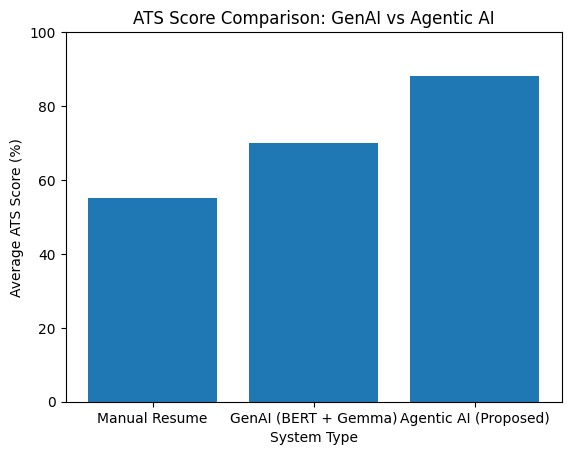

In [37]:
tracker.track("What is the proposed methodology?")
tracker.track("What datasets were used?")
tracker.track("What are the main results?")
tracker.track("What are the conclusions of the paper?")

In [38]:
plot_rag_analytics(tracker)

---

## Analytics Summary

Total Queries: 4
Average Response Time: 1.63
Average Retrieval Time: 0.05
Average LLM Time: 1.58
Average Confidence: 0.571


In [33]:
# Ek cell mein run karo
if pdf_images:
    print(pdf_images[0].keys())
    print("Example values:")
    for k, v in pdf_images[0].items():
        if k != 'base64' and k != 'data':  # base64 skip karo, bohot lamba hoga
            print(f"  {k}: {v}")
else:
    print("pdf_images empty hai!")

dict_keys(['page_num', 'img_idx', 'pil_img', 'caption', 'nearby_context', 'description'])
Example values:
  page_num: 4
  img_idx: 0
  pil_img: <PIL.Image.Image image mode=RGB size=1536x1024 at 0x7C260C608B30>
  caption: 
  nearby_context: P. Patil, L. Rathod, P. Chalawadi
Fig. 1. Architecture of the Proposed Agentic AI Resume Builder System
3.3
Dataset Description
The system suggested does not require any special dataset to train or fi
  description: Description unavailable.
